# Y.Afisha Marketing Analysis

## Objective
Analyze user behavior, sales patterns and marketing spend for Y.Afisha to optimize investment allocation across acquisition channels.

## Data Sources
- `visits_log_us.csv` — website sessions (Jan 2017 - Dec 2018)
- `orders_log_us.csv` — completed orders
- `costs_us.csv` — marketing spend by acquisition source

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
# Function to clean column names by stripping whitespace, converting to lowercase, and replacing spaces with underscores
def clean_column_names(df):
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_'))
    return df

# 1. Data Loading and Preparation

## Dataset 1: Visits Log

In [3]:
# Load the visits log data
df_visits = pd.read_csv('./data/visits_log_us.csv')

In [4]:
# Display basic information about the DataFrame and its memory usage
df_visits.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  str   
 1   End Ts     359400 non-null  str   
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  str   
 4   Uid        359400 non-null  uint64
dtypes: int64(1), str(3), uint64(1)
memory usage: 71.1 MB


In [5]:
# Check df head to understand the structure of the data
print(df_visits.head(6))

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  


In [6]:
# Check options in the 'Device' column
print(df_visits['Device'].value_counts())

Device
desktop    262567
touch       96833
Name: count, dtype: int64


In [7]:
# Check options in the 'Source Id' column
print(df_visits['Source Id'].value_counts())

Source Id
4     101794
3      85610
5      66905
2      47626
1      34121
9      13277
10     10025
7         36
6          6
Name: count, dtype: int64


## Observations
- `Device` has only 2 unique values (`desktop`, `touch`) — should be converted to `category`
- `Source Id` has only 9 unique values — should be converted to `category`
- `Start Ts` / `End Ts` loaded as `str` — should be converted to `datetime`
- `Uid` is `uint64` — appropriate, no change needed
- Column names contain spaces and uppercase — will be standardized to `snake_case`
- Memory usage: 71.1 MB — expected to reduce after optimization

In [8]:
# Reload the data with optimized data types and parse date columns
df_visits = pd.read_csv(
    './data/visits_log_us.csv',
    dtype={'Device': 'category', 'Source Id': 'category'},
    parse_dates=['Start Ts', 'End Ts'])

In [9]:
# Display basic information about the DataFrame and its memory usage after optimization
df_visits.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[us]
 2   Source Id  359400 non-null  category      
 3   Start Ts   359400 non-null  datetime64[us]
 4   Uid        359400 non-null  uint64        
dtypes: category(2), datetime64[us](2), uint64(1)
memory usage: 8.9 MB


In [10]:
# Clean column names to avoid issues
df_visits = clean_column_names(df_visits)

In [11]:
# Display the cleaned column names to verify the changes
print(df_visits.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='str')


In [12]:
# Check for duplicates
print(f"df_visits number of duplicate rows: {df_visits.duplicated().sum()}")

df_visits number of duplicate rows: 0


In [13]:
# Check for null values
print(f"Null values in each column:\n{df_visits.isnull().sum()}")

Null values in each column:
device       0
end_ts       0
source_id    0
start_ts     0
uid          0
dtype: int64


## Dataset 2: Orders

In [14]:
# Load the orders log data
df_orders = pd.read_csv('./data/orders_log_us.csv')

In [15]:
# Display basic information about the orders DataFrame and its memory usage
df_orders.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  str    
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), str(1), uint64(1)
memory usage: 4.0 MB


In [16]:
# Check df head to understand the structure of the data
print(df_orders.head(6))

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321


## Observations
- `Buy Ts` loaded as `str` — should be converted to `datetime`
- Column names contain spaces and uppercase — will be standardized to `snake_case`
- `Revenue` is `float64` — appropriate for monetary values, no change needed
- `Uid` is `uint64` — appropriate, no change needed
- Memory usage: 4.0 MB — already small, minimal improvement expected after optimization

In [17]:
# Reload the orders data with optimized data types and parse date columns
df_orders = pd.read_csv(
    './data/orders_log_us.csv',
    parse_dates=['Buy Ts'])

In [18]:
# Display basic information about the DataFrame and its memory usage after optimization
df_orders.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[us]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [19]:
# Clean column names to avoid issues
df_orders = clean_column_names(df_orders)

In [20]:
# Display the cleaned column names to verify the changes
print(df_orders.columns)

Index(['buy_ts', 'revenue', 'uid'], dtype='str')


In [21]:
# Check for duplicate rows
print(f"df_orders duplicate rows: {df_orders.duplicated().sum()}")

df_orders duplicate rows: 0


In [22]:
# Check for null values
print(f"Null values in each column:\n{df_orders.isnull().sum()}")

Null values in each column:
buy_ts     0
revenue    0
uid        0
dtype: int64


## Dataset 3: Marketing Costs

In [23]:
# Load the marketing costs data
df_marketing_costs = pd.read_csv('./data/costs_us.csv')

In [24]:
# Display basic information about the marketing costs DataFrame and its memory usage
df_marketing_costs.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   str    
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 186.3 KB


In [25]:
# Check sources in the 'source_id' column
print(df_marketing_costs['source_id'].value_counts())

source_id
5     364
1     363
2     363
3     363
4     363
9     363
10    363
Name: count, dtype: int64


In [26]:
# Check df head to understand the structure of the data
print(df_marketing_costs.head(6))

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39


## Observations
- `source_id` has only 7 unique values — should be converted to `category`
- `dt` loaded as `str` — should be converted to `datetime`
- Column names already in `snake_case` — `clean_column_names()` applied for consistency
- `costs` is `float64` — appropriate for monetary values, no change needed
- Memory usage: 183.3 KB — already small, minimal improvement expected after optimization

In [27]:
# Reload the marketing costs data with optimized data types and parse date columns
df_marketing_costs = pd.read_csv('./data/costs_us.csv', dtype={'source_id': 'category'},
                                 parse_dates=['dt'])

In [28]:
# Display basic information about the DataFrame and its memory usage after optimization
df_marketing_costs.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   category      
 1   dt         2542 non-null   datetime64[us]
 2   costs      2542 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(1)
memory usage: 43.0 KB


In [29]:
# Clean column names to avoid issues
df_marketing_costs = clean_column_names(df_marketing_costs)

In [30]:
# Display the cleaned column names to verify the changes
print(df_marketing_costs.columns)

Index(['source_id', 'dt', 'costs'], dtype='str')


In [31]:
# Check for duplicate rows
print(
    f"df_marketing_costs duplicate rows: {df_marketing_costs.duplicated().sum()}")

df_marketing_costs duplicate rows: 0


In [32]:
# Check for null values
print(f"Null values in each column:\n{df_marketing_costs.isnull().sum()}")

Null values in each column:
source_id    0
dt           0
costs        0
dtype: int64


## Data Preparation Summary


### Optimization Results
| Dataset | Rows | Before | After | Reduction |
|---|---|---|---|---|
| `df_visits` | 359,400 | 71.1 MB | 8.9 MB | -87% |
| `df_orders` | 50,415 | 4.0 MB | 1.2 MB | -70% |
| `df_marketing_costs` | 2,542 | 183.3 KB | 43.0 KB | -77% |

### Changes Applied
| Dataset | Column | Change |
|---|---|---|
| `df_visits` | `device` | `str` → `category` |
| `df_visits` | `source_id` | `int64` → `category` |
| `df_visits` | `start_ts`, `end_ts` | `str` → `datetime` |
| `df_orders` | `buy_ts` | `str` → `datetime` |
| `df_marketing_costs` | `source_id` | `int64` → `category` |
| `df_marketing_costs` | `dt` | `str` → `datetime` |
| All datasets | column names | standardized to `snake_case` |

### Cross-dataset Observations
- Source IDs `6` and `7` appear in `df_visits` (6 and 36 rows respectively) 
but have no entries in `df_marketing_costs`, suggesting these may represent 
organic or unpaid traffic channels such as direct access or word of mouth.
- No missing values or duplicates found in any dataset.

# 2. Product Analysis

## 2.1 Daily, Weekly and Monthly Active Users (DAU / WAU / MAU)

In [33]:
# Extract year, month, week, and date from 'start_ts' for time-based analysis
df_visits['session_year'] = df_visits['start_ts'].dt.year
df_visits['session_month'] = df_visits['start_ts'].dt.month
df_visits['session_week'] = df_visits['start_ts'].dt.isocalendar().week
df_visits['session_date'] = df_visits['start_ts'].dt.date

In [34]:
# Check first few rows to verify the new columns
print(df_visits.head(6))

    device              end_ts source_id            start_ts  \
0    touch 2017-12-20 17:38:00         4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00         2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00         5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00         9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00         3 2017-12-27 14:06:00   
5  desktop 2017-09-03 21:36:00         5 2017-09-03 21:35:00   

                    uid  session_year  session_month  session_week  \
0  16879256277535980062          2017             12            51   
1    104060357244891740          2018              2             8   
2   7459035603376831527          2017              7            26   
3  16174680259334210214          2018              5            20   
4   9969694820036681168          2017             12            52   
5  16007536194108375387          2017              9            35   

  session_date  
0   2017-12-20  
1   2018-02-19  
2   2017-

In [35]:
# Calculate Daily Active Users (DAU) by counting unique user IDs per session date
dau = df_visits.groupby('session_date').agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'dau'})
# Check the first few rows of the DAU DataFrame to verify the results
print(dau.head(6))

  session_date  dau
0   2017-06-01  605
1   2017-06-02  608
2   2017-06-03  445
3   2017-06-04  476
4   2017-06-05  820
5   2017-06-06  797


In [36]:
# Calculate Weekly Active Users (WAU) by counting unique user IDs per session week
wau = df_visits.groupby(['session_year', 'session_week']).agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'wau'})
# Check the first few rows of the WAU DataFrame to verify the results
print(wau.head(6))

   session_year  session_week   wau
0          2017            22  2021
1          2017            23  4129
2          2017            24  2812
3          2017            25  2878
4          2017            26  3064
5          2017            27  3294


In [37]:
# Calculate Monthly Active Users (MAU) by counting unique user IDs per session month
mau = df_visits.groupby(['session_year', 'session_month']).agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'mau'})
# Check the first few rows of the MAU DataFrame to verify the results
print(mau.head(6))

   session_year  session_month    mau
0          2017              6  13259
1          2017              7  14183
2          2017              8  11631
3          2017              9  18975
4          2017             10  29692
5          2017             11  32797


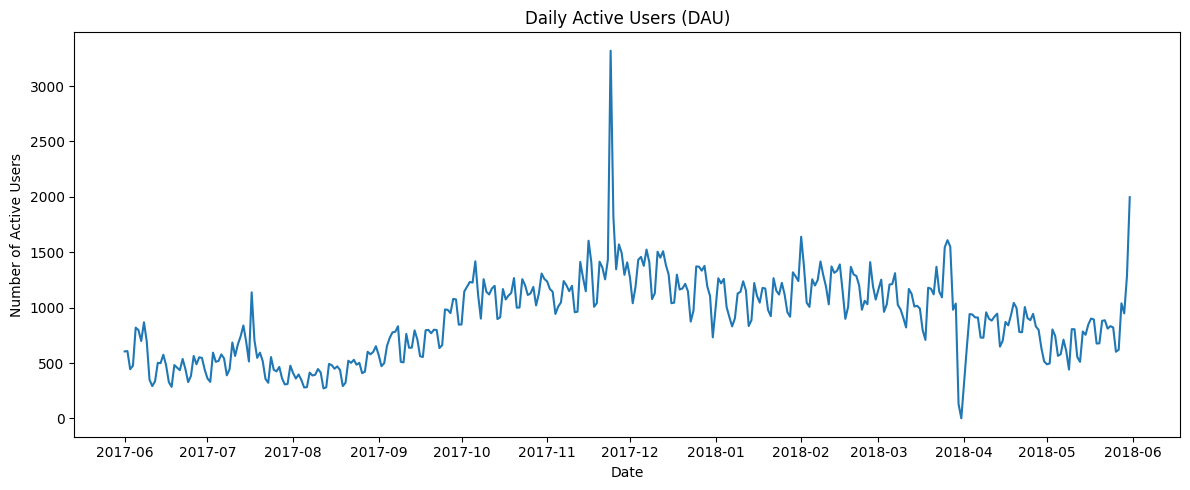

In [38]:
# Plot Daily Active Users (DAU)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dau['session_date'], dau['dau'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Daily Active Users (DAU)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Users')
plt.tight_layout()
plt.show()

### Observations — DAU
- Overall growth in the number of active users throughout the data period (Jun 2017 — Jun 2018)
- Substantial and sustained increase in DAU from summer to autumn 2017, with average daily users approximately doubling
- Regular daily oscillations throughout the period, likely reflecting weekday vs weekend usage patterns
- Anomalous peak in December 2017 — possibly related to a promotional campaign or seasonal event
- Near-zero DAU in April 2018 — likely due to a platform outage or server downtime

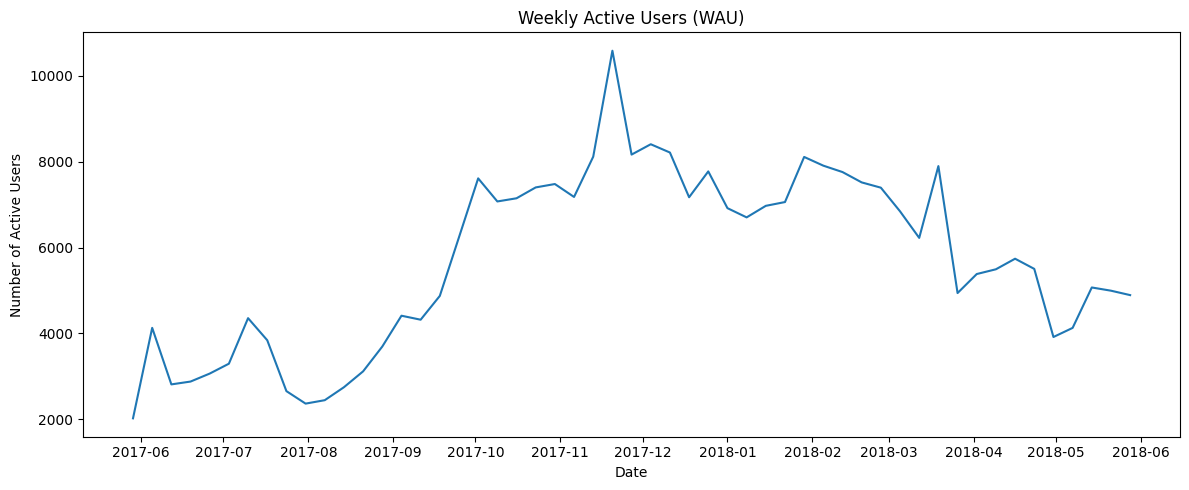

In [39]:
# Plot Weekly Active Users (WAU)
wau['date'] = pd.to_datetime(wau['session_year'].astype(
    str) + '-W' + wau['session_week'].astype(str) + '-1', format='%Y-W%W-%w')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wau['date'], wau['wau'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Weekly Active Users (WAU)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Users')
plt.tight_layout()
plt.show()

### Observations — WAU
- Significant and sustained growth in WAU from June to December 2017, with weekly active users approximately tripling over this period
- Sharp peak in late November / early December 2017 — consistent with the anomalous spike observed in the DAU graph, possibly related to a promotional campaign or seasonal event
- Elevated WAU levels maintained from December 2017 through March 2018
- Sharp drop in April 2018 — consistent with the platform outage identified in the DAU analysis
- No significant recovery after April 2018 — WAU remains below pre-outage levels for the remainder of the period

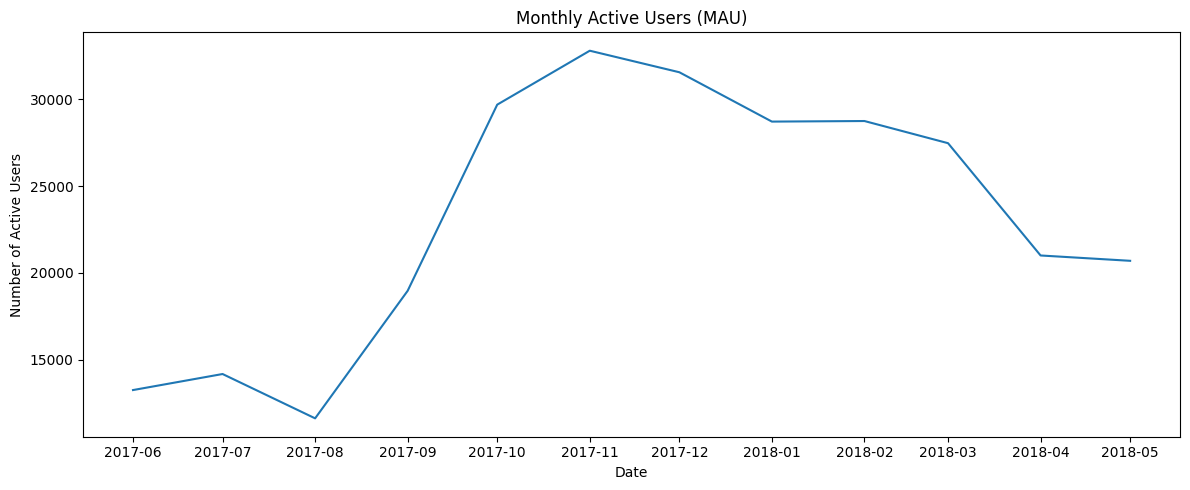

In [40]:
# Plot Monthly Active Users (MAU)
mau['date'] = pd.to_datetime(mau['session_year'].astype(
    str) + '-' + mau['session_month'].astype(str), format='%Y-%m')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mau['date'], mau['mau'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Monthly Active Users (MAU)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Users')
plt.tight_layout()
plt.show()

### Observations — MAU
- Steady growth from June to December 2017, with MAU approximately tripling over this period — consistent with the trend observed in DAU and WAU
- Peak in December 2017, aligning with the anomalous spike identified in the DAU and WAU charts
- Elevated MAU maintained from December 2017 through March 2018, suggesting the growth was not purely seasonal
- Sharp drop in April 2018, consistent with the platform outage identified in the DAU and WAU analysis
- MAU smooths out the daily and weekly noise, confirming that the overall growth and the April 2018 disruption are structural events, not statistical artefacts

## 2.2 Sessions per Day

In [41]:
# Calculate the number of sessions per day
user_data = df_visits.groupby('session_date').agg(
    n_sessions=('uid', 'count')).reset_index()

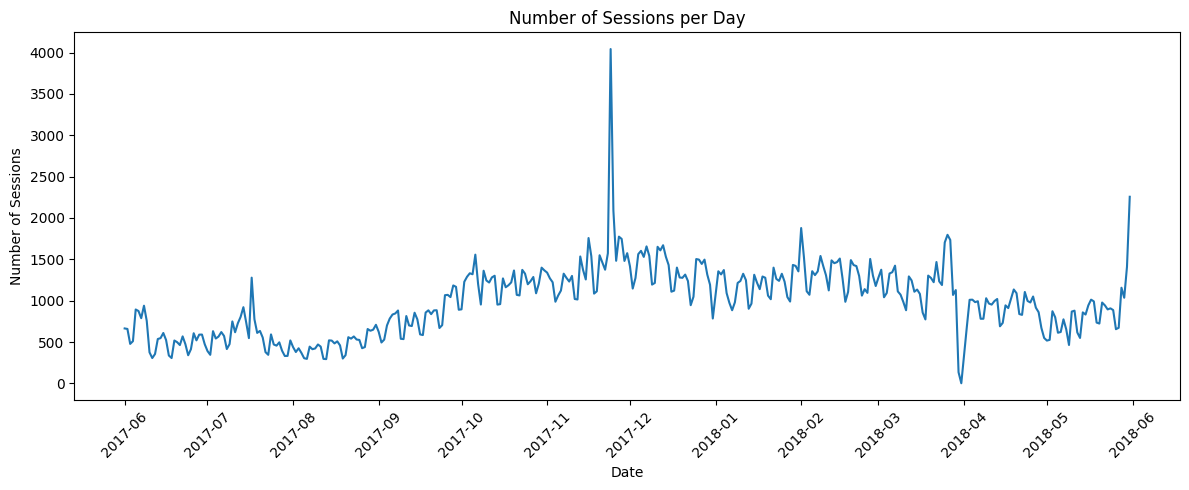

In [42]:
# Plot total number of sessions per day over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(user_data['session_date'], user_data['n_sessions'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Number of Sessions per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Sessions per Day
- The daily session count closely mirrors the DAU trend, confirming that most users generate exactly one session per day
- Sessions consistently exceed unique users each day, indicating a small fraction of users return more than once daily
- The same growth pattern from summer to autumn 2017, December peak, and April 2018 drop are visible — consistent with the DAU analysis
- Daily oscillations persist, reflecting the weekday vs weekend usage pattern observed in DAU

## 2.3 Session Duration

In [43]:
# Calculate session duration in seconds
df_visits['session_duration_sec'] = (
    df_visits['end_ts'] - df_visits['start_ts']).dt.total_seconds()

In [44]:
# Run descriptive statistics on session duration to understand its distribution
print(df_visits['session_duration_sec'].describe())

count    359400.000000
mean        643.025687
std         997.127761
min       -2760.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       42660.000000
Name: session_duration_sec, dtype: float64


### Data Quality Issues — Session Duration
- At least one session has a negative duration, which is impossible in practice — `end_ts` is recorded before `start_ts`, indicating a data error.
- Maximum duration is unusually large (42,660 seconds, approximately 11.8 hours), likely caused by users leaving the browser open rather than actively using the platform.
- Both cases will be filtered before analysis.

In [45]:
# Get the 99th percentile of session duration to identify potential outliers
p99 = df_visits['session_duration_sec'].quantile(0.99)

In [46]:
# Filter out sessions with duration less than 1 second or greater than the 99th percentile to focus on typical user behavior
df_visits = df_visits[(df_visits['session_duration_sec'] > 0) & (
    df_visits['session_duration_sec'] <= p99)]

In [47]:
# Verify session duration distribution after filtering
print(df_visits['session_duration_sec'].describe())

count    320107.000000
mean        647.840728
std         745.983163
min          19.000000
25%         120.000000
50%         360.000000
75%         900.000000
max        4500.000000
Name: session_duration_sec, dtype: float64


### After Filtering
- After filtering, ~39,000 rows were removed using two filters: 
sessions with negative duration (data errors) and outliers above the 99th percentile
- Min is now 19 seconds — consistent with a quick website visit
- Median is 360 seconds (~6 minutes) — sufficient time to browse and purchase a ticket
- Max is 4,500 seconds (~75 minutes) — plausible for an engaged user browsing multiple events

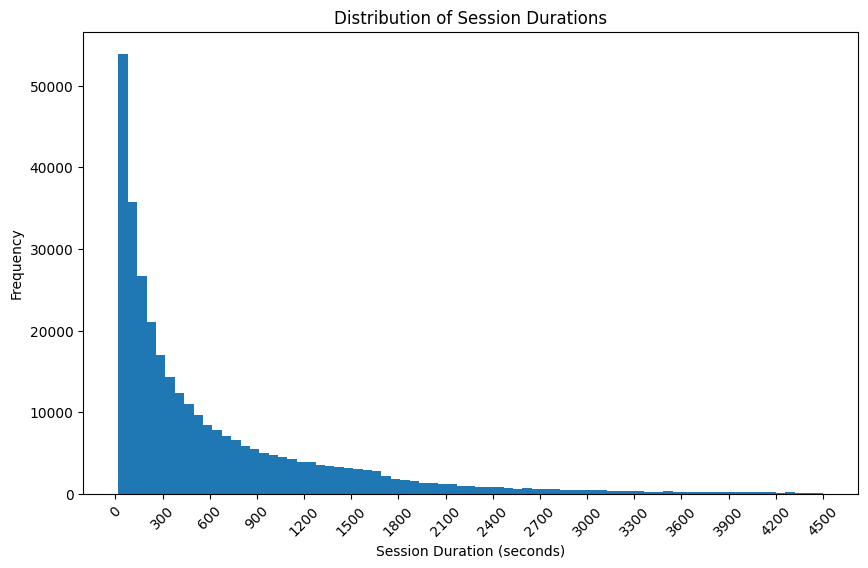

In [48]:
# Plot duration of sessions
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_visits['session_duration_sec'], bins=75)
plt.xticks(rotation=45)
ax.set_xlabel('Session Duration (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Session Durations')
# Set x-axis ticks every 5 minutes (300 seconds)
ax.xaxis.set_major_locator(plt.MultipleLocator(300))
plt.show()

### Observations — Session Duration
- The distribution is right-skewed, indicating that most users spend a short 
amount of time on the platform — typical behaviour for a ticket sales website 
where users visit with a specific purchase intent
- The median session duration is ~6 minutes, which is consistent with the time 
needed to browse events and complete a purchase

## 2.4 How Often Do Users Return?

In [49]:
# Calculate the timestamp of the first visit for each user to analyze user retention and cohort behavior
first_visit = df_visits.groupby('uid')['start_ts'].min()
first_visit.name = 'first_visit_ts'

In [50]:
# Join the first visit timestamp back to the original visits DataFrame
df_visits = df_visits.join(first_visit, on='uid')

In [51]:
# Extract week and year of the current visit and the first visit to analyze user retention and cohort behavior
df_visits['visit_week'] = df_visits['start_ts'].dt.isocalendar().week
df_visits['visit_year'] = df_visits['start_ts'].dt.year
df_visits['first_visit_week'] = df_visits['first_visit_ts'].dt.isocalendar().week
df_visits['first_visit_year'] = df_visits['first_visit_ts'].dt.year

In [52]:
# Calculate weeks elapsed between each visit and the user's first visit
df_visits['cohort_lifetime'] = (
    pd.to_datetime(df_visits['visit_year'].astype(str) + '-W' + df_visits['visit_week'].astype(str) + '-1', format='%Y-W%W-%w') -
    pd.to_datetime(df_visits['first_visit_year'].astype(
        str) + '-W' + df_visits['first_visit_week'].astype(str) + '-1', format='%Y-W%W-%w')
)

In [53]:
# Convert cohort lifetime from timedelta to weeks and round to the nearest integer
df_visits['cohort_lifetime'] = df_visits['cohort_lifetime'] / \
    np.timedelta64(1, 'W')
df_visits['cohort_lifetime'] = df_visits['cohort_lifetime'].round().astype(int)

In [54]:
# Create a cohort column based on the first visit year and week
df_visits['cohort'] = pd.to_datetime(
    df_visits['first_visit_year'].astype(str) + '-W' +
    df_visits['first_visit_week'].astype(str) + '-1',
    format='%Y-W%W-%w'
)

In [55]:
# Group by cohort lifetime, first visit year, and first visit week to calculate the number of unique users in each cohort over time
grouped_cohorts = df_visits.groupby(['cohort_lifetime', 'cohort']).agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'n_users'})

In [56]:
# Extract the number of users in the initial week (cohort lifetime = 0) for each cohort to analyze user retention and cohort behavior
initial_users = grouped_cohorts[grouped_cohorts['cohort_lifetime'] == 0][[
    'cohort', 'n_users']]

# rename the n_users column to initial_users for clarity
initial_users = initial_users.rename(columns={'n_users': 'initial_users'})

In [57]:
# merge the initial users back to the grouped cohorts DataFrame to calculate retention rates
grouped_cohorts = grouped_cohorts.merge(initial_users, on='cohort', how='left')

In [58]:
# calculate retention rate
grouped_cohorts['retention_rate'] = grouped_cohorts['n_users'] / \
    grouped_cohorts['initial_users']

In [59]:
# Pivot retention rates: rows = cohorts, columns = lifetime weeks
cohort_pivot = grouped_cohorts.pivot_table(
    index='cohort', columns='cohort_lifetime', values='retention_rate', aggfunc='mean')

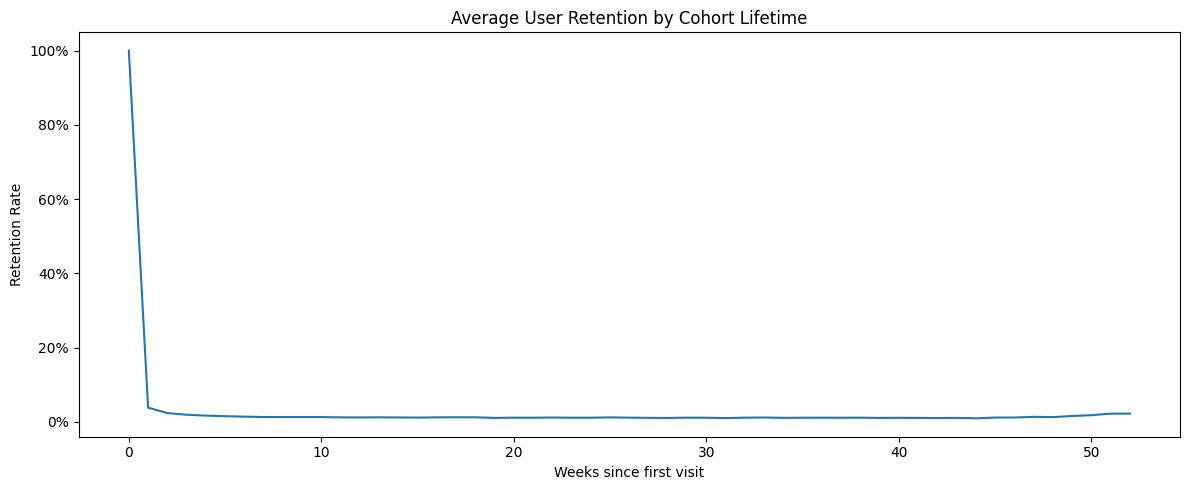

In [60]:
# Plot average retention rate across all cohorts by week
retention_by_lifetime = grouped_cohorts.groupby(
    'cohort_lifetime')['retention_rate'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(retention_by_lifetime.index, retention_by_lifetime.values)
ax.set_title('Average User Retention by Cohort Lifetime')
ax.set_xlabel('Weeks since first visit')
ax.set_ylabel('Retention Rate')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.show()

### Observations — User Retention
- Retention drops sharply after week 1, indicating that most users do not return after their first visit — typical for a ticket sales platform where purchases are infrequent
- By week 4, retention stabilises at a low level, suggesting a small but consistent core of repeat users
- The low long-term retention confirms that Y.Afisha relies heavily on acquiring new users rather than retaining existing ones — marketing spend efficiency is therefore critical

# 3. Sales Analysis
The `df_visits` dataframe is reloaded here to ensure a clean state before merging with `df_orders`.

In [61]:
# Reloading the visits dataframe
df_visits = pd.read_csv(
    './data/visits_log_us.csv',
    dtype={'Device': 'category', 'Source Id': 'category'},
    parse_dates=['Start Ts', 'End Ts'])

In [62]:
# Clean column names to avoid issues
df_visits = clean_column_names(df_visits)

## 3.1 When Do Users Start Buying?

In [63]:
# Calculate the timestamp of the first visit for each user
first_visit = df_visits.groupby('uid')['start_ts'].min()
first_visit.name = 'first_visit_ts'

In [64]:
# Join the first visit timestamp back to the original visits DataFrame
df_visits = df_visits.join(first_visit, on='uid')

In [65]:
# Calculate the timestamp of the first purchase for each user
first_purchase = df_orders.groupby('uid')['buy_ts'].min()
first_purchase.name = 'first_purchase_ts'

In [66]:
# Join the first purchase timestamp back to the original orders DataFrame
df_orders = df_orders.join(first_purchase, on='uid')

In [67]:
# Merge visits and orders data on 'uid' to analyze the relationship between user visits and purchases
visits_orders = df_visits.merge(df_orders, on='uid', how='left')

In [68]:
# Confirm the merge results
print(visits_orders.head(6))

    device              end_ts source_id            start_ts  \
0    touch 2017-12-20 17:38:00         4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00         2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00         5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00         9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00         3 2017-12-27 14:06:00   
5  desktop 2017-09-03 21:36:00         5 2017-09-03 21:35:00   

                    uid      first_visit_ts              buy_ts  revenue  \
0  16879256277535980062 2017-12-20 17:20:00                 NaT      NaN   
1    104060357244891740 2018-02-19 16:53:00                 NaT      NaN   
2   7459035603376831527 2017-07-01 01:54:00                 NaT      NaN   
3  16174680259334210214 2018-03-09 20:05:00 2018-03-09 20:25:00     2.33   
4   9969694820036681168 2017-12-27 14:06:00                 NaT      NaN   
5  16007536194108375387 2017-09-03 21:35:00 2017-09-04 12:46:00     2.44   

    first_purchase

In [69]:
# Filtering only users who made a purchase
first_conversion = visits_orders.dropna(
    subset=['first_purchase_ts']).drop_duplicates('uid')

In [70]:
# Calculate the time to purchase in days for each user
time_to_purchase = (
    first_conversion['first_purchase_ts'] - first_conversion['first_visit_ts']).dt.days

In [71]:
# Run descriptive statistics on time to purchase to understand its distribution
print(time_to_purchase.describe())

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
dtype: float64


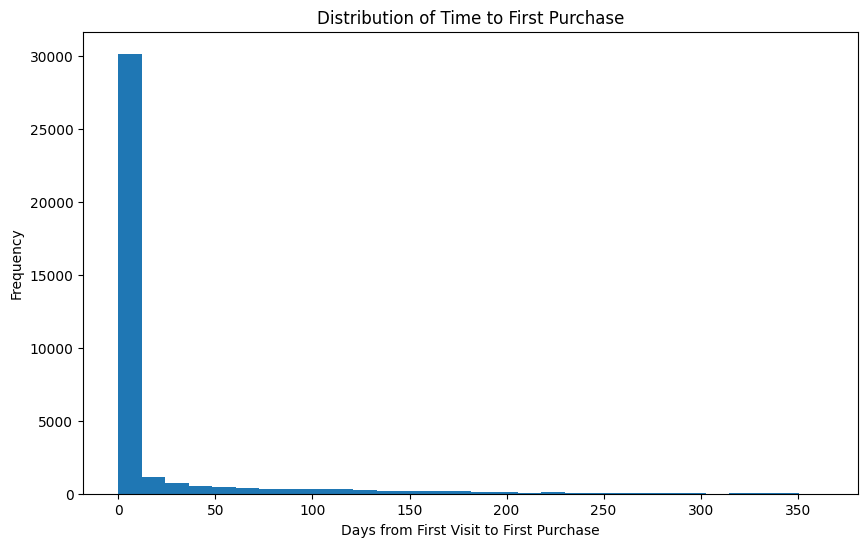

In [72]:
# Plot distribution of time from first visit to first purchase
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(time_to_purchase, bins=30)
ax.set_xlabel('Days from First Visit to First Purchase')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Time to First Purchase')
plt.show()

### Observations — When Do Users Start Buying?
- The majority of converting users make their first purchase on the same day as their first visit — median time to purchase is 0 days
- 75% of users convert within 2 days of their first visit, indicating a strong and fast purchase intent
- The distribution is right-skewed, with some users taking up to 363 days to convert — suggesting a small segment of users that require a longer consideration period
- The mean time to purchase is 16 days, significantly higher than the median due to the long tail — median is a more representative metric here

## 3.2 Orders per User

In [73]:
# Calculate the number of orders per user
orders_count = df_orders.groupby('uid').agg(
    {'buy_ts': 'count'}).reset_index().rename(columns={'buy_ts': 'orders_count'})

In [74]:
# Define sales cohorts based on the month of first purchase
df_orders['first_order_month'] = df_orders['first_purchase_ts'].dt.to_period(
    'M')

In [75]:
# Merge the orders DataFrame with the orders count to analyze sales cohorts and user purchasing behavior
sales_cohort = df_orders.merge(orders_count, on='uid', how='left')

In [76]:
# Group by user ID to get the first order count and sales cohort for each user
cohort_grouped_user = sales_cohort.groupby('uid').agg(
    {'orders_count': 'first', 'first_order_month': 'first'}).reset_index()

In [77]:
# Run descriptive statistics on orders count to understand the distribution of user purchasing behavior
print(cohort_grouped_user['orders_count'].describe())

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: orders_count, dtype: float64


In [78]:
# Check frequency of each order count value to identify the outlier range
print(cohort_grouped_user['orders_count'].value_counts().sort_index().head(20))

orders_count
1     30231
2      4395
3      1086
4       375
5       147
6        79
7        41
8        24
9         7
10       15
11        8
12       10
13        8
14        4
15        5
16        7
17        6
18        3
19        4
20        1
Name: count, dtype: int64


### Data Quality Note — Orders per User
- Maximum of 239 orders for a single user — likely a bot or data anomaly
- 75th percentile is 1, confirming a heavily right-skewed distribution
- Users above the 99th percentile will be excluded from the distribution plot to avoid distorting the visualisation

In [79]:
# Filter out users above the 99th percentile of orders count to remove potential bots or anomalies
p99_orders = cohort_grouped_user['orders_count'].quantile(0.99)
orders_filtered = cohort_grouped_user[cohort_grouped_user['orders_count'] <= p99_orders]
print(
    f"99th percentile: {p99_orders} orders | Users removed: {len(cohort_grouped_user) - len(orders_filtered)}")

99th percentile: 5.0 orders | Users removed: 289


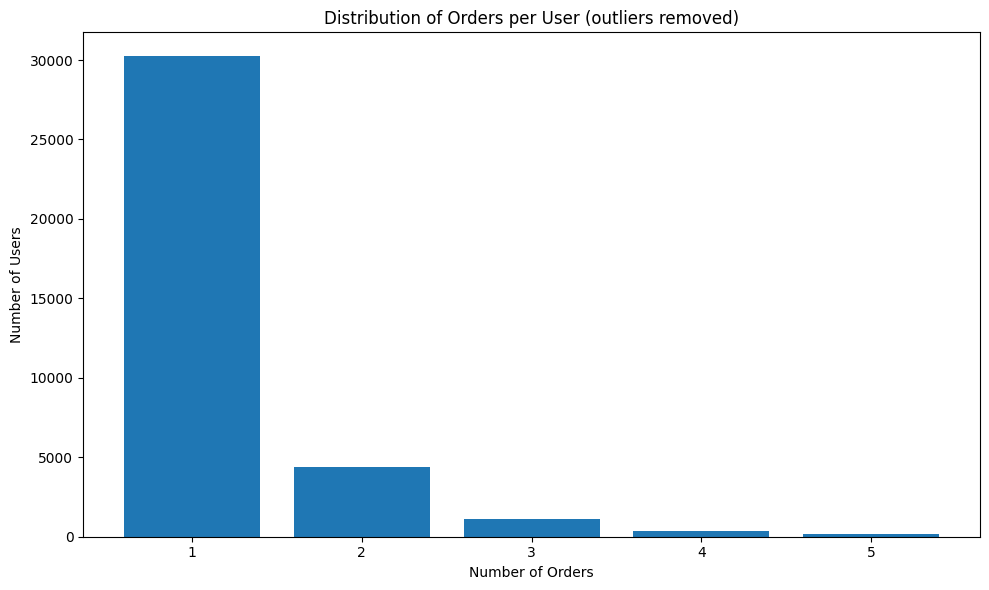

In [80]:
# Plot distribution of orders per user using value_counts for discrete data
order_dist = orders_filtered['orders_count'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(order_dist.index, order_dist.values)
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Users')
ax.set_title('Distribution of Orders per User (outliers removed)')
plt.tight_layout()
plt.show()

In [81]:
# Calculate average orders per user by sales cohort
grouped_by_cohort = cohort_grouped_user.groupby(
    'first_order_month').agg({'orders_count': 'mean'}).reset_index().rename(columns={'orders_count': 'avg_orders_per_user'})

In [82]:
# Display the average orders per user by sales cohort
print(grouped_by_cohort)

   first_order_month  avg_orders_per_user
0            2017-06             2.193772
1            2017-07             1.513261
2            2017-08             1.597080
3            2017-09             1.502518
4            2017-10             1.383641
5            2017-11             1.445724
6            2017-12             1.344741
7            2018-01             1.277201
8            2018-02             1.224322
9            2018-03             1.269176
10           2018-04             1.181898
11           2018-05             1.087349
12           2018-06             1.000000


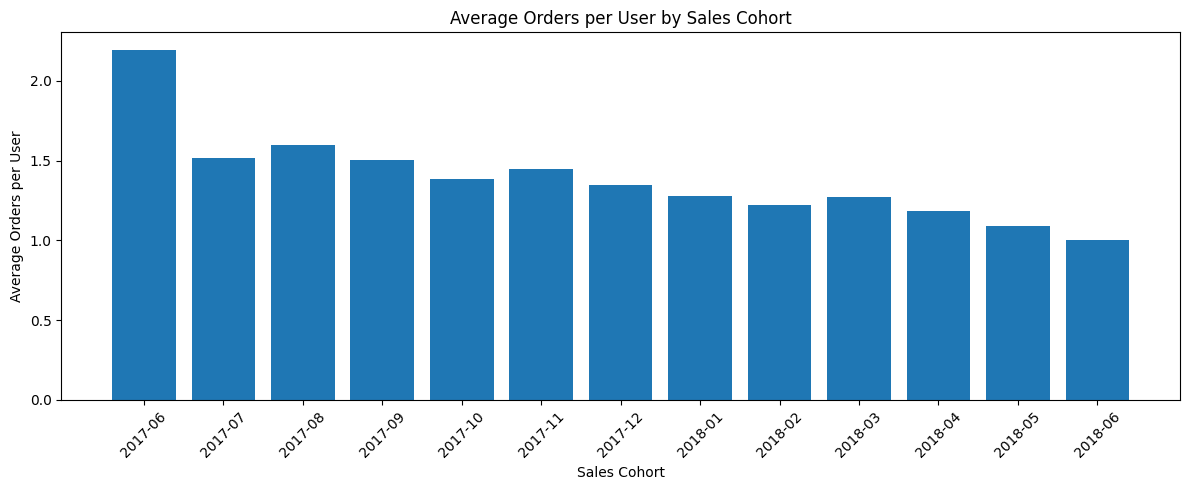

In [83]:
# Plot average orders per user by sales cohort
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(grouped_by_cohort['first_order_month'].astype(str),
       grouped_by_cohort['avg_orders_per_user'])
ax.set_xlabel('Sales Cohort')
ax.set_ylabel('Average Orders per User')
ax.set_title('Average Orders per User by Sales Cohort')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Average Orders per User by Sales Cohort
- The June 2017 cohort shows the highest average orders per user (~2.2), while the most recent cohorts approach 1.0
- This declining trend is largely explained by the observation window — older cohorts had more time to accumulate purchases, while recent cohorts (e.g. June 2018) only had a few weeks of data available
- Despite this bias, even the earliest cohorts average only ~2 orders per user over the entire period, suggesting that most users are one-time or ccasional buyers
- This reinforces the finding from section 3.a — most users convert quickly and make few repeat purchases, which is typical behaviour for a ticket sales platform

## 3.3 Average Purchase Value

In [84]:
# Extract purchase month from 'buy_ts' to analyze sales trends over time
df_orders['purchase_month'] = df_orders['buy_ts'].dt.to_period('M')

In [85]:
# Calculate average revenue per purchase month to analyze sales trends over time
average_purchase_month = df_orders.groupby('purchase_month').agg(
    {'revenue': 'mean'}).reset_index().rename(columns={'revenue': 'avg_revenue'})

In [86]:
# Check the average revenue per month with all data
print(f"Overall average purchase value: {df_orders['revenue'].mean():.2f}")

Overall average purchase value: 5.00


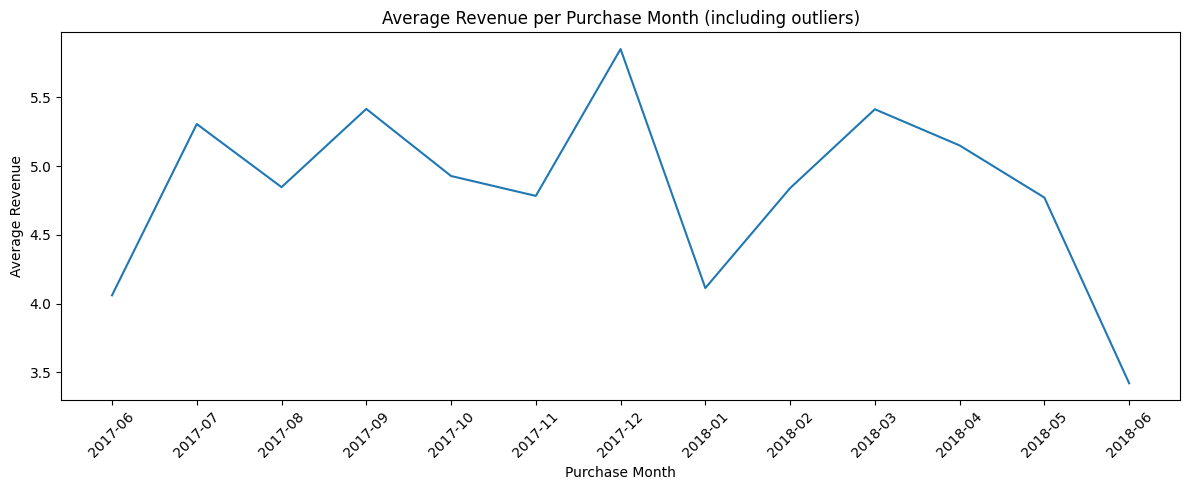

In [87]:
# Plot average revenue per purchase month (including outliers)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(average_purchase_month['purchase_month'].astype(str),
        average_purchase_month['avg_revenue'])
ax.set_xlabel('Purchase Month')
ax.set_ylabel('Average Revenue')
ax.set_title('Average Revenue per Purchase Month (including outliers)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Average Purchase Value
- Average purchase value shows an unstable pattern throughout the period, with consecutive months alternating between increases and decreases
- After every monthly peak, the following month consistently shows a decline — suggesting a "spend and recover" pattern in user purchasing behaviour
- The highest average purchase value occurs in December 2017 (~5.8), likely driven by Christmas festivities and gift purchases
- January 2018 shows a sharp drop - typical post-holiday behaviour where users who spent heavily in December reduce spending the following month
- No clear upward or downward trend overall — average purchase value remains relatively stable between ~4 and ~5.5 throughout most of the period, with June 2018 being an exception at ~3.4

In [88]:
# Run descriptive statistics on revenue to understand its distribution
print(df_orders['revenue'].describe())

count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: revenue, dtype: float64


In [89]:
# Get the 99th percentile of revenue to identify potential outliers
p99_revenue = df_orders['revenue'].quantile(0.99)
print(f"99th percentile of revenue: {p99_revenue:.2f}")

99th percentile of revenue: 36.67


### Data Quality Note — Revenue Outliers
- The raw data contains a maximum purchase value of 2,633.28 — significantly above the 99th percentile of 36.67
- This may represent a data entry error or a bulk/corporate purchase that is not representative of typical user behaviour
- The chart below removes values above the 99th percentile to better reflect typical purchasing patterns — both versions are shown for transparency

In [90]:
# Filter out orders above the 99th percentile of revenue to remove potential outliers and analyze typical purchase behavior
df_orders_filtered = df_orders[df_orders['revenue'] <= p99_revenue]
print(
    f"99th percentile: {p99_revenue} | Users removed: {len(df_orders) - len(df_orders_filtered)}")

99th percentile: 36.67 | Users removed: 465


In [91]:
# Show descriptive statistics of revenue after filtering out outliers
print(df_orders_filtered['revenue'].describe())

count    49950.000000
mean         3.999020
std          4.531477
min          0.000000
25%          1.220000
50%          2.440000
75%          4.890000
max         36.670000
Name: revenue, dtype: float64


In [92]:
# Check overall average purchase value without outliers
print(
    f"Overall average purchase value: {df_orders_filtered['revenue'].mean():.2f}")

Overall average purchase value: 4.00


In [93]:
# Calculate average revenue per purchase month to analyze sales trends over time
average_purchase_month_filtered = df_orders_filtered.groupby('purchase_month').agg(
    {'revenue': 'mean'}).reset_index().rename(columns={'revenue': 'avg_revenue'})
print(average_purchase_month_filtered)

   purchase_month  avg_revenue
0         2017-06     3.607523
1         2017-07     4.734780
2         2017-08     4.541075
3         2017-09     4.192084
4         2017-10     4.166407
5         2017-11     4.093963
6         2017-12     3.912615
7         2018-01     3.681103
8         2018-02     3.879043
9         2018-03     3.880344
10        2018-04     4.122737
11        2018-05     3.763465
12        2018-06     3.420000


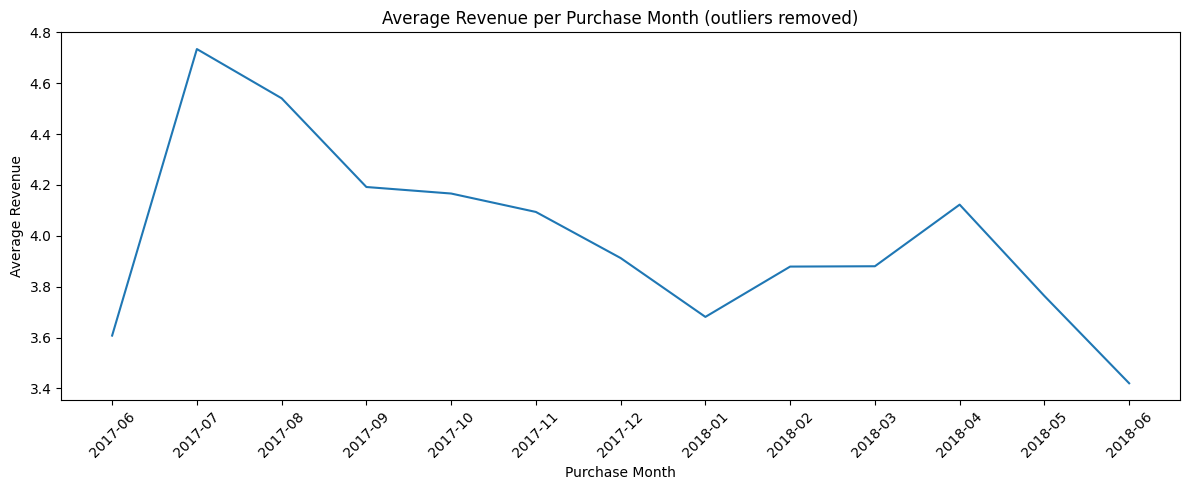

In [94]:
# Plot average revenue per purchase month to analyze sales trends over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(average_purchase_month_filtered['purchase_month'].astype(str),
        average_purchase_month_filtered['avg_revenue'])
ax.set_xlabel('Purchase Month')
ax.set_ylabel('Average Revenue')
ax.set_title('Average Revenue per Purchase Month (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Average Purchase Value
- After removing outliers above the 99th percentile (36.67), the average purchase value ranges between ~3.4 and ~4.7 throughout the period
- The highest average purchase value occurs in July 2017 (~4.7), followed by a gradual decline through the remainder of the period
- A general downward trend is visible from mid-2017 onwards, suggesting that average purchase value has been declining over time
- The lowest average purchase value is recorded in June 2018 (~3.4), which may be partially explained by the platform outage identified earlier reducing high-value purchases in that period
- Unlike the unfiltered data, no strong seasonal pattern is visible after outlier removal — the December 2017 spike disappears, suggesting it was driven by a small number of high-value purchases rather than a broad increase in typical user spending

## 3.4 Lifetime Value (LTV)

In [95]:
# Calculate LTV per user by summing revenue for each user and their first order month to analyze customer lifetime value by cohort
ltv_per_user = df_orders.groupby(['uid', 'first_order_month']).agg(
    ltv=('revenue', 'sum')).reset_index()

In [96]:
# Calculate average LTV per cohort to analyze customer lifetime value by cohort
avg_ltv_cohort = ltv_per_user.groupby('first_order_month').agg(
    avg_ltv=('ltv', 'mean')).reset_index()

In [97]:
# Display the average LTV per cohort
print(avg_ltv_cohort)

   first_order_month    avg_ltv
0            2017-06  11.879234
1            2017-07   8.386854
2            2017-08   8.471723
3            2017-09  13.435227
4            2017-10   6.360242
5            2017-11   6.395244
6            2017-12   7.639913
7            2018-01   4.940151
8            2018-02   4.587921
9            2018-03   5.455253
10           2018-04   5.189196
11           2018-05   4.660562
12           2018-06   3.420000


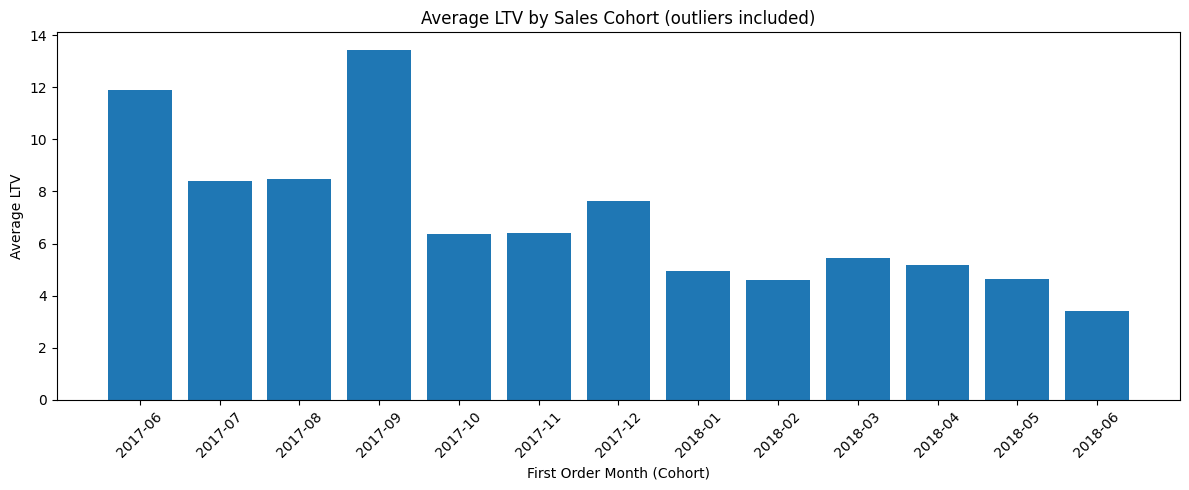

In [98]:
# Plot average LTV by cohort
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(avg_ltv_cohort['first_order_month'].astype(str),
       avg_ltv_cohort['avg_ltv'])
ax.set_xlabel('First Order Month (Cohort)')
ax.set_ylabel('Average LTV')
ax.set_title('Average LTV by Sales Cohort (outliers included)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Average LTV by Cohort (including outliers)
- The September 2017 cohort shows the highest average LTV (~13.4), followed by June 2017 (~11.9) — both being early cohorts with more time to accumulate purchases
- A general declining trend is visible from older to more recent cohorts, largely explained by the observation window bias — newer cohorts had less time to generate revenue
- December 2017 shows an unexpected spike (~7.7) compared to surrounding cohorts — likely driven by high-value outlier purchases, which inflates the average LTV for that cohort
- The presence of outliers (max revenue 2,633.28) may be significantly distorting the LTV for some cohorts — a filtered version is shown below for comparison
- September 2017 (~13.4) being higher than June 2017 (~11.9) despite June being an older cohort is suspicious — June had more time to accumulate revenue yet September is higher. This is almost certainly an outlier order in September inflating that cohort's average.

In [99]:
# Calculate LTV per user without outliers
ltv_per_user_filtered = df_orders_filtered.groupby(['uid', 'first_order_month']).agg(
    ltv=('revenue', 'sum')).reset_index()

In [100]:
# Calculate average LTV per cohort without outliers
avg_ltv_cohort_filtered = ltv_per_user_filtered.groupby('first_order_month').agg(
    avg_ltv=('ltv', 'mean')).reset_index()

In [101]:
# Display the average LTV per cohort without outliers
print(avg_ltv_cohort_filtered)

   first_order_month   avg_ltv
0            2017-06  9.407110
1            2017-07  6.984830
2            2017-08  7.738977
3            2017-09  6.747160
4            2017-10  5.473388
5            2017-11  5.646517
6            2017-12  5.084281
7            2018-01  4.548264
8            2018-02  4.413651
9            2018-03  4.688308
10           2018-04  4.713322
11           2018-05  4.010920
12           2018-06  3.420000


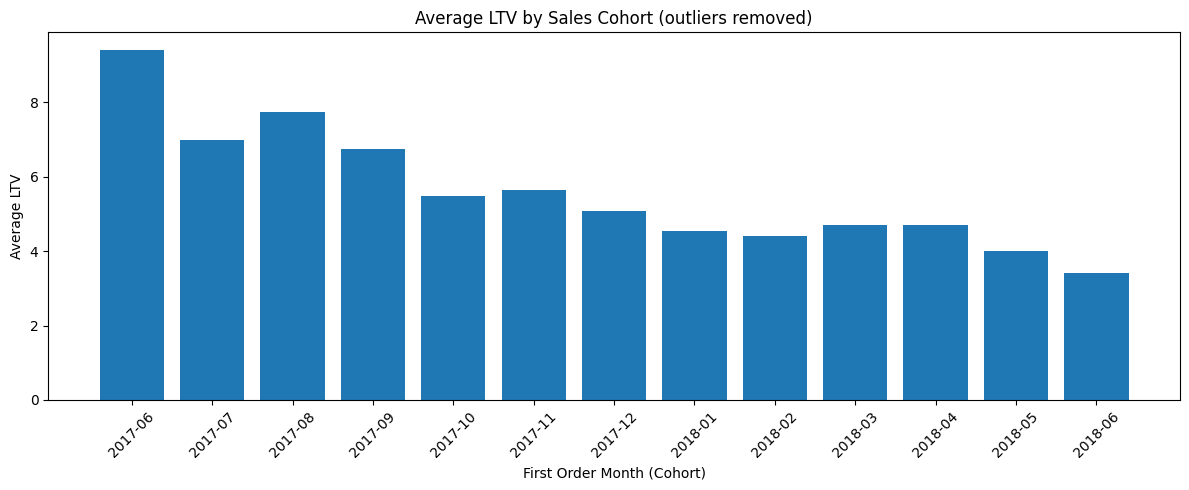

In [102]:
# Plot average LTV by cohort without outliers
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(avg_ltv_cohort_filtered['first_order_month'].astype(str),
       avg_ltv_cohort_filtered['avg_ltv'])
ax.set_xlabel('First Order Month (Cohort)')
ax.set_ylabel('Average LTV')
ax.set_title('Average LTV by Sales Cohort (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Average LTV by Cohort (outliers removed)
- After removing outliers, June 2017 is now the cohort with the highest average LTV (~9.4) — consistent with it being the oldest cohort with the most time to accumulate purchases
- The September 2017 anomaly disappears — confirming it was driven by outlier purchases rather than genuine high-value customer behaviour
- The December 2017 spike also disappears — reinforcing that the Christmas peak was caused by a small number of high-value orders, not a broad increase in typical user spending
- A consistent and gradual declining trend is now clearly visible from older to more recent cohorts — almost entirely explained by the observation window bias
- Some minor fluctuations remain (July 2017, October 2017, February 2018) but these are small and likely due to natural variation in cohort size

# 4. Costs Analysis

## 4.1 Marketing  (total, per source, during time)

In [103]:
# Check descriptive statistics of marketing costs
print(df_marketing_costs['costs'].describe())

count    2542.000000
mean      129.477427
std       156.296628
min         0.540000
25%        21.945000
50%        77.295000
75%       170.065000
max      1788.280000
Name: costs, dtype: float64


In [104]:
# Check to which source the maximum marketing cost is attributed
print(df_marketing_costs[df_marketing_costs['costs']
      == df_marketing_costs['costs'].max()])

    source_id         dt    costs
902         3 2017-11-24  1788.28


In [105]:
total_costs = df_marketing_costs['costs'].sum()
print(f'Total marketing costs during the full period: {total_costs:.2f}')

Total marketing costs during the full period: 329131.62


In [106]:
# Group marketing costs by source
marketing_costs_by_source = df_marketing_costs.groupby('source_id')[
    'costs'].sum()
marketing_costs_by_source = marketing_costs_by_source.reset_index().rename(
    columns={'costs': 'total_costs'}).sort_values(by='total_costs', ascending=False)
print(marketing_costs_by_source)

  source_id  total_costs
3         3    141321.63
4         4     61073.60
5         5     51757.10
2         2     42806.04
0         1     20833.27
1        10      5822.49
6         9      5517.49


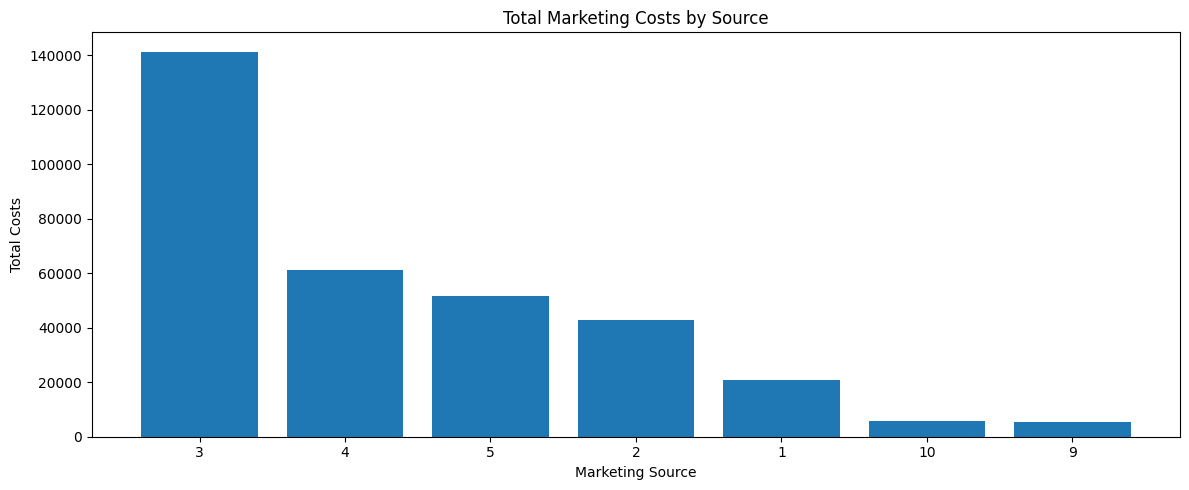

In [107]:
# Ploting bar chart of total marketing costs by source
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(marketing_costs_by_source['source_id'].astype(str),
       marketing_costs_by_source['total_costs'])
ax.set_xlabel('Marketing Source')
ax.set_ylabel('Total Costs')
ax.set_title('Total Marketing Costs by Source')
plt.tight_layout()
plt.show()

### Observations — Total Marketing Costs by Source
- Total marketing spend across all sources: ~329,131
- Source 3 is by far the largest investment (~141,321), representing approximately 43% of total marketing spend
- The maximum daily cost of 1,788.28 belongs to Source 3 — given the scale of investment in this channel, this is not an outlier but rather a normal high-spend day
- Source 4 is the second largest (~61,073) and Source 5 the third (~51,757) — together with Source 3 they account for ~77% of total spend
- Sources 9 and 10 represent minimal investment (~6,000 each) — likely experimental or low-priority channels


In [108]:
# Adding column with month when cost occurred
df_marketing_costs['cost_month'] = df_marketing_costs['dt'].dt.to_period('M')
print(df_marketing_costs.head(6))

  source_id         dt  costs cost_month
0         1 2017-06-01  75.20    2017-06
1         1 2017-06-02  62.25    2017-06
2         1 2017-06-03  36.53    2017-06
3         1 2017-06-04  55.00    2017-06
4         1 2017-06-05  57.08    2017-06
5         1 2017-06-06  40.39    2017-06


In [109]:
# Get marketing costs per month
costs_per_month = df_marketing_costs.groupby('cost_month').agg(
    monthly_costs=('costs', 'sum')).reset_index()
print(costs_per_month.sort_values(by='cost_month'))
print(costs_per_month.sort_values(by='cost_month').count())

   cost_month  monthly_costs
0     2017-06       18015.00
1     2017-07       18240.59
2     2017-08       14790.54
3     2017-09       24368.91
4     2017-10       36322.88
5     2017-11       37907.88
6     2017-12       38315.35
7     2018-01       33518.52
8     2018-02       32723.03
9     2018-03       30415.27
10    2018-04       22289.38
11    2018-05       22224.27
cost_month       12
monthly_costs    12
dtype: int64


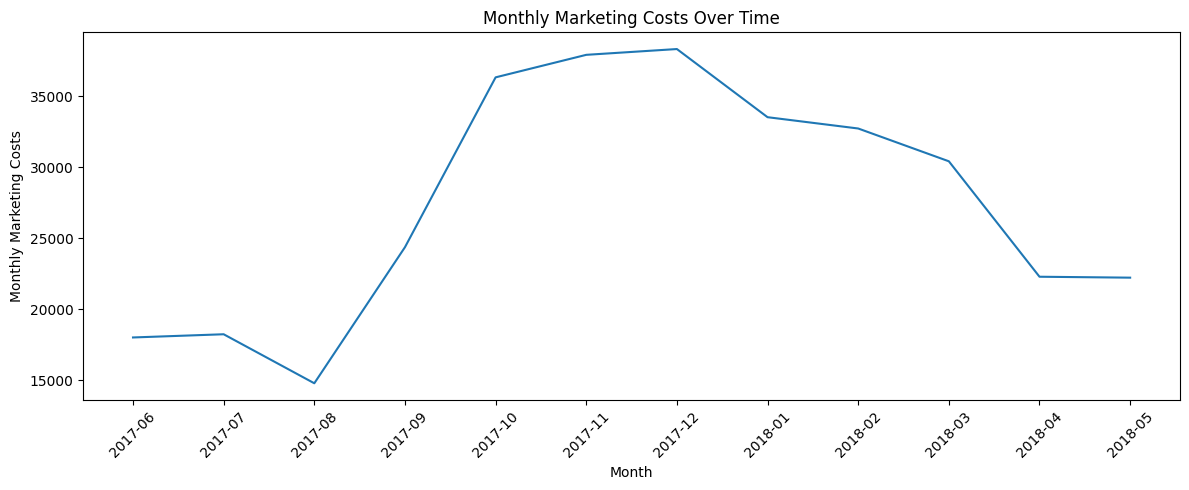

In [110]:
# Plot line chart of marketing costs per month
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(costs_per_month['cost_month'].astype(str),
        costs_per_month['monthly_costs'])
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Marketing Costs')
ax.set_title('Monthly Marketing Costs Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Monthly Marketing Costs Over Time
- Marketing spend grew steadily from June 2017 (~18K) to a peak in December 2017 (~38K), more than doubling over six months — this ramp-up aligns with the DAU/WAU/MAU growth observed in section 2, suggesting the increased spend was driving user acquisition
- A notable acceleration occurs in October 2017 (~36K), marking the start of a sustained high-spend period through December 2017
- August 2017 shows a brief dip (~14.8K) — the only month where spend decreased before the autumn ramp-up
- Spend declines consistently from January 2018 onwards, dropping from ~33.5K to ~22K by May 2018 — mirroring the decline in active users seen in the same period
- No marketing investment is recorded in June 2018 — any traffic or orders in that month came exclusively from organic or unpaid sources

## 4.2 Customer Acquisition Cost (CAC)

In [111]:
# Reload df_visits to ensure a clean state before marketing analysis
df_visits = pd.read_csv(
    './data/visits_log_us.csv',
    dtype={'Device': 'category', 'Source Id': 'category'},
    parse_dates=['Start Ts', 'End Ts']
)
df_visits = clean_column_names(df_visits)

In [112]:
# Calculate the timestamp of the first visit for each user
first_visit = df_visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid', 'first_visit_ts']

In [113]:
# Get user source data
user_source = first_visit.merge(df_visits[['uid', 'start_ts', 'source_id']],  # select only necessary columns
                                # keys on first visit
                                left_on=['uid', 'first_visit_ts'],
                                # keys on df_visits
                                right_on=['uid', 'start_ts'])

# Eliminating redundant columns after merge
user_source = user_source.drop(columns=['start_ts'])

In [114]:
# Extracting the month of the first visit for cohort analysis
user_source['first_visit_month'] = user_source['first_visit_ts'].dt.to_period(
    'M')

In [115]:
# Calculating the number of unique users in each cohort
source_cohort = user_source.groupby(['first_visit_month', 'source_id']).agg(
    n_users=('uid', 'nunique')).reset_index()

In [116]:
# Calculate total marketing costs per source
costs_cohort = df_marketing_costs.groupby(['cost_month', 'source_id']).agg(
    total_costs=('costs', 'sum')).reset_index()

In [117]:
# Merging user cohorts with marketing costs
source_costs_cohort = source_cohort.merge(costs_cohort,
                                          left_on=[
                                              'first_visit_month', 'source_id'],
                                          right_on=['cost_month', 'source_id'],
                                          how='outer')

# Eliminating redundant columns after merge
source_costs_cohort = source_costs_cohort.drop(columns=['cost_month'])

In [118]:
# Calculate Customer Acquisition Cost (CAC)
source_costs_cohort['cac'] = source_costs_cohort['total_costs'] / \
    source_costs_cohort['n_users']

# Eliminate rows where CAC is NaN (which occur because there are no costs)
source_costs_cohort = source_costs_cohort.dropna(subset=['cac'])

In [119]:
print(source_costs_cohort.head(6))

  first_visit_month source_id  n_users  total_costs       cac
0           2017-06         1      631      1125.61  1.783851
1           2017-06        10      396       314.22  0.793485
2           2017-06         2     1262      2427.38  1.923439
3           2017-06         3     4080      7731.65  1.895012
4           2017-06         4     3447      3514.80  1.019669
5           2017-06         5     2728      2616.12  0.958988


In [120]:
# Pivoting the data for easier analysis of CAC by cohort and source
cac_pivot = source_costs_cohort.pivot_table(
    index='first_visit_month',
    columns='source_id',
    values='cac',
    aggfunc='mean')

In [121]:
# Sorting columns by average CAC
cac_pivot = cac_pivot.reindex(cac_pivot.mean().sort_values().index, axis=1)

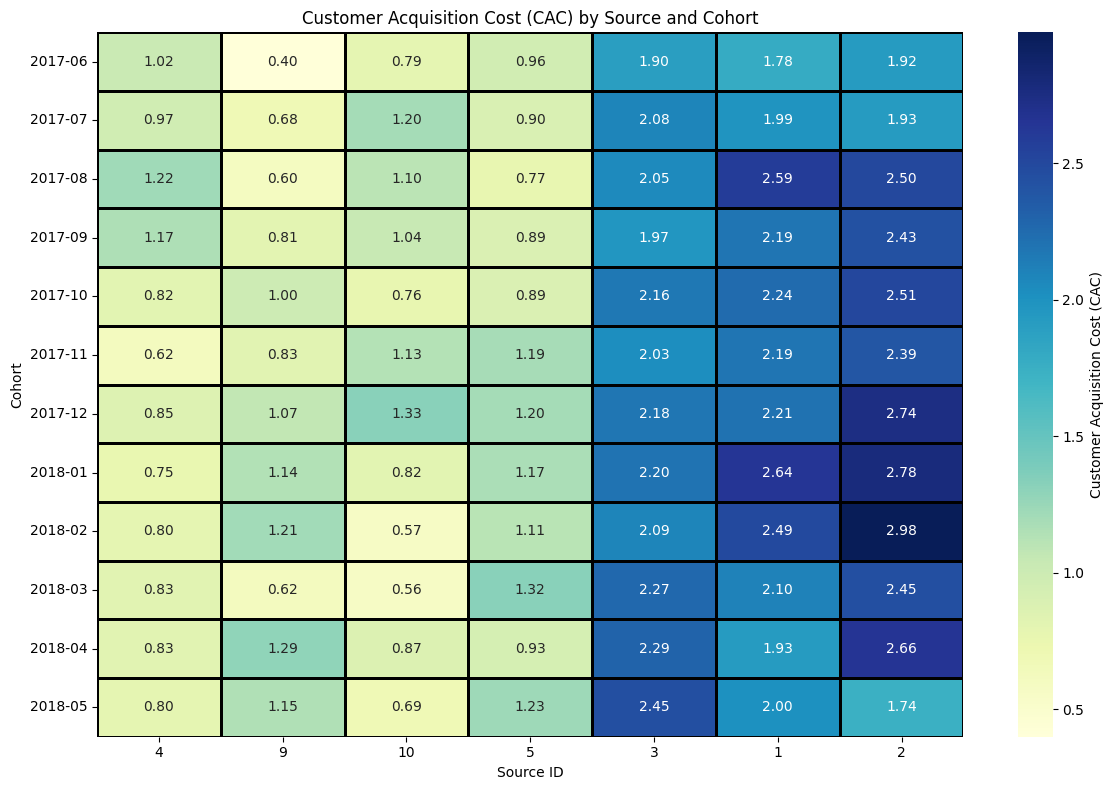

In [122]:
# Plotting heatmap of CAC by cohort and source
plt.figure(figsize=(12, 8))
plt.title('Customer Acquisition Cost (CAC) by Source and Cohort')
sns.heatmap(
    cac_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Customer Acquisition Cost (CAC)'},
    linewidths=2,
    linecolor='black'
)
plt.xlabel('Source ID')
plt.ylabel('Cohort')
plt.tight_layout()
plt.show()

In [123]:
# Displaying total users, total costs, and average CAC
print(source_costs_cohort.groupby('source_id').agg(
    total_users=('n_users', 'sum'),
    total_costs=('total_costs', 'sum'),
    avg_cac=('cac', 'mean')
).sort_values('avg_cac'))

           total_users  total_costs   avg_cac
source_id                                    
4                72346     61073.60  0.889874
9                 6448      5517.49  0.900366
10                6903      5822.49  0.905963
5                49237     51757.10  1.047218
3                66116    141321.63  2.140098
1                 9469     20833.27  2.196375
2                17616     42806.04  2.418852


### Observations — Customer Acquisition Cost (CAC) by Source

| Source | Total Users | Total Costs | Avg CAC |
|---|---|---|---|
| 4 | 72,346 | 61,073 | 0.89 |
| 9 | 6,448 | 5,517 | 0.90 |
| 10 | 6,903 | 5,822 | 0.91 |
| 5 | 49,237 | 51,757 | 1.05 |
| 3 | 66,116 | 141,321 | 2.14 |
| 1 | 9,469 | 20,833 | 2.20 |
| 2 | 17,616 | 42,806 | 2.42 |

- Source 4 is the most efficient channel — lowest CAC (~0.89) and highest number of users acquired (72,346), making it the best performer in terms of acquisition efficiency
- Sources 9 and 10 also show low CAC (~0.90) but with significantly lower volume — they may be efficient but limited in scale
- Source 3 receives the largest investment (141,321) but has a CAC of 2.14 — not the most efficient channel despite the high spend
- Source 2 has the highest CAC (2.42) with relatively low user volume (17,616) — the least efficient channel for user acquisition
- CAC alone is not sufficient to evaluate channel performance — it must be compared with LTV to assess true ROI, which is analysed in the next section

## 4.3 Return on Investment (ROI)

In [132]:
# Merging user source data with LTV per user to analyze LTV by source
ltv_by_user = user_source.merge(ltv_per_user_filtered, on='uid', how='left')

# Filling NaN LTV values with 0 for users who did not make a purchase
ltv_by_user['ltv'] = ltv_by_user['ltv'].fillna(0)

In [134]:
# Calculating total LTV by cohort and source
cohort_source_ltv = ltv_by_user.groupby(['first_visit_month', 'source_id']).agg(
    total_ltv=('ltv', 'sum')
).reset_index()

In [135]:
# Mergeing total LTV by cohort and source with source costs cohort to analyze ROI by cohort and source
roi_cohort = cohort_source_ltv.merge(
    costs_cohort,
    left_on=['first_visit_month', 'source_id'],
    right_on=['cost_month', 'source_id']
)

In [ ]:
# Creating LTV/CAC ratio column to analyze the efficiency of marketing spend by cohort and source
roi_cohort['ltv_cac_ratio'] = roi_cohort['total_ltv'] / \
    roi_cohort['total_costs']

# Creating ROI column to analyze the return on investment of marketing spend by cohort and source
roi_cohort['roi'] = (roi_cohort['total_ltv'] -
                     roi_cohort['total_costs']) / roi_cohort['total_costs']

In [137]:
roi_pivot = roi_cohort.pivot_table(
    index='first_visit_month',
    columns='source_id',
    values='roi',
    aggfunc='mean'
)

In [138]:
print(roi_pivot)

source_id                 1        10         2         3         4         5  \
first_visit_month                                                               
2017-06            5.156466  0.024378  1.140003 -0.398982  0.574374  0.812027   
2017-07            0.792568 -0.135347  0.140953 -0.500914  0.099144  0.094389   
2017-08            0.610122 -0.219633 -0.430601 -0.593405 -0.298506  0.710980   
2017-09            0.176663 -0.422971 -0.050250 -0.566931 -0.337200  0.222668   
2017-10            0.126287 -0.014795 -0.380448 -0.621476 -0.056728 -0.095544   
2017-11           -0.237097 -0.176549 -0.303769 -0.652270  0.231604 -0.488187   
2017-12           -0.240159 -0.571548 -0.544155 -0.656905 -0.265248 -0.374315   
2018-01           -0.526649 -0.398258 -0.580640 -0.735219 -0.340761 -0.490275   
2018-02           -0.435264 -0.455332 -0.632071 -0.731418 -0.296175 -0.469246   
2018-03           -0.456418  0.035847 -0.533826 -0.751754 -0.329333 -0.565476   
2018-04           -0.417156 

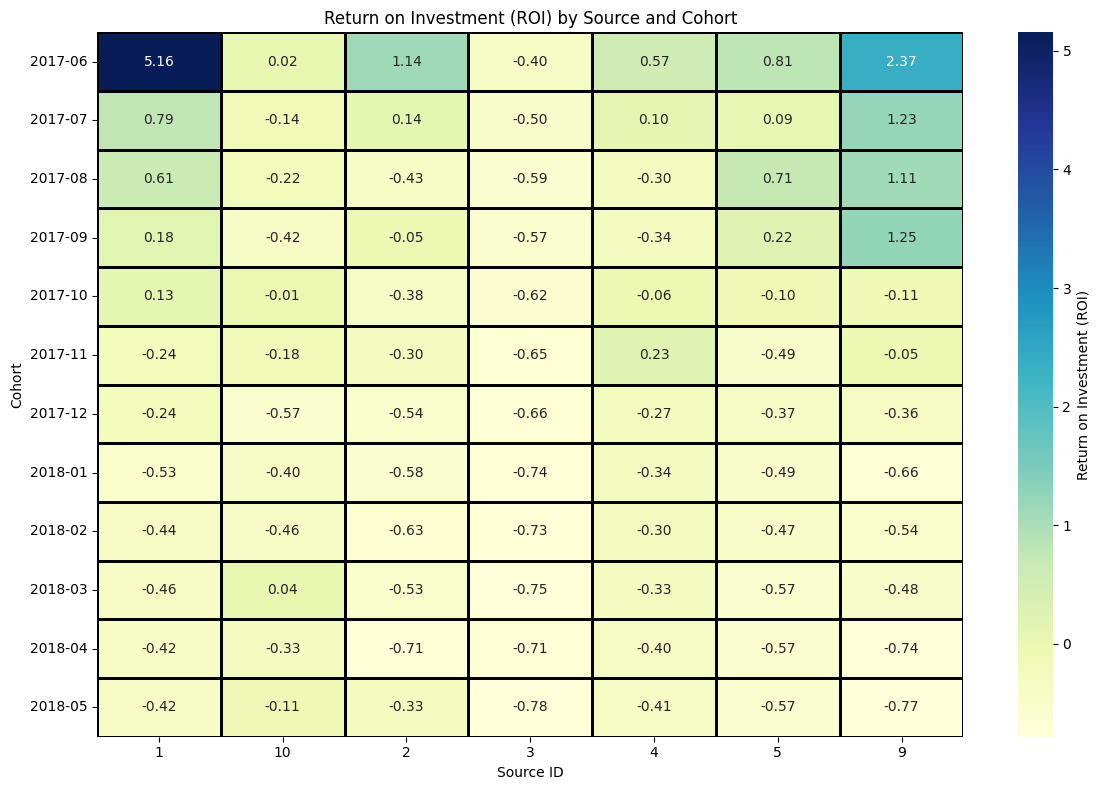

In [139]:
# Plotting heatmap of ROI by cohort and source
plt.figure(figsize=(12, 8))
plt.title('Return on Investment (ROI) by Source and Cohort')
sns.heatmap(roi_pivot,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            cbar_kws={'label': 'Return on Investment (ROI)'},
            linewidths=2,
            linecolor='black'
            )
plt.xlabel('Source ID')
plt.ylabel('Cohort')
plt.tight_layout()
plt.show()

### Observations — Return on Investment (ROI) by Source and Cohort

- **Source 1** shows the strongest overall ROI, with a peak of 5.16 in June 2017 — driven by a low CAC combined with a reasonable LTV, making it the most efficient channel in terms of return
- **Source 9** also shows positive ROI in early cohorts but turns negative from late 2017 onwards — suggesting diminishing returns over time
- **Source 3**, despite receiving the largest marketing investment (~141k), consistently shows negative or near-zero ROI across most cohorts — indicating that the high spend is not being recovered through revenue
- A clear pattern emerges across all sources: **older cohorts (2017) show higher ROI than more recent ones (2018)** — largely explained by the observation window bias, as older cohorts had more time to generate revenue
- From late 2017 onwards, most sources show negative ROI — suggesting that marketing spend was not being efficiently converted into revenue in this period

## 5. Conclusions and Marketing Recommendations

### Key Findings
- Most users convert quickly — over 50% make their first purchase on the same day as their first visit, with 75% converting within 2 days
- Average purchase value is relatively stable (~3.4 to 4.7) with no clear upward trend — growth must come from acquiring more users, not higher spend per user
- LTV and ROI are significantly higher for older cohorts — marketing investment should be evaluated over a 6-month horizon, not month-by-month

### Recommendations

**Increase investment in Source 1**
Despite not having the lowest CAC (€2.20), Source 1 consistently delivers the highest ROI across cohorts — the users it acquires generate more revenue per euro invested than any other channel.

**Reduce investment in Source 3**
Source 3 receives 43% of total marketing spend (~€141k) but shows consistently negative ROI across almost all cohorts. This is the most critical reallocation opportunity — redirecting this budget to higher-performing channels could significantly improve overall marketing efficiency.

**Monitor Source 4**
Source 4 has the lowest CAC (0.89) and the highest user volume (72,346). Although ROI values are not strongly positive, the efficiency of acquisition makes it a strong candidate for increased investment if LTV can be improved through retention strategies.

**Evaluate marketing investment over a 6-month horizon**
ROI is consistently higher for older cohorts — users need time to generate revenue after acquisition. Marketing decisions based on short-term ROI will systematically undervalue channels that attract loyal, repeat buyers.

**Investigate Sources 9 and 10**
Both show low CAC (~0.90) with limited scale — if volume can be increased while maintaining efficiency, these could become valuable acquisition channels.